# Прогнозирование снижения покупательской активности клиентов интернет-магазина

   **Цель проекта** 
   
Цель проекта — разработать модель машинного обучения, которая позволит **прогнозировать вероятность снижения покупательской активности клиентов интернет-магазина в ближайшие три месяца**, а также выполнить **сегментацию покупателей** для формирования практических бизнес-рекомендаций по удержанию клиентов.

   **Задачи проекта**
В рамках проекта необходимо:

- провести анализ и предобработку исходных данных;
- изучить поведенческие, маркетинговые и финансовые особенности клиентов;
- построить и сравнить несколько моделей классификации;
- выбрать лучшую модель по метрике ROC-AUC;
- интерпретировать результаты модели;
- сегментировать покупателей с учётом риска снижения активности и прибыльности;
- сформулировать рекомендации для ключевых сегментов клиентов.



## Шаг . Загрузка данных

На этом этапе загружаем исходные данные из файлов, предоставленных заказчиком.
Данные находятся в нескольких таблицах и содержат информацию:

- о поведении покупателей на сайте,
- о коммуникациях с клиентами,
- о продуктовом и финансовом поведении покупателей.

Загрузка данных выполняется с учётом возможных особенностей формата:
в некоторых файлах используется разделитель `;`, а десятичный разделитель — `,`.

На данном этапе проводится первичная проверка структуры данных
и соответствия столбцов описанию из технического задания.


ЯЧЕЙКА 1 — импорты

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder
)

from sklearn.impute import SimpleImputer

from sklearn.metrics import roc_auc_score, classification_report

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC


RANDOM_STATE = 42


In [2]:
!pip install shap
import shap

     |████████████████████████████████| 999 kB 1.6 MB/s eta 0:00:01


ЯЧЕЙКА 2 — ЗАГРУЗКА ДАННЫХ

In [3]:
market = pd.read_csv('/datasets/market_file.csv', sep=',')
market_money = pd.read_csv('/datasets/market_money.csv', sep=',')
market_time = pd.read_csv('/datasets/market_time.csv', sep=',')
money = pd.read_csv('/datasets/money.csv', sep=';')

ЯЧЕЙКА 3 — ИСПРАВЛЕНИЕ ФОРМАТА ПРИБЫЛИ

In [4]:
money['Прибыль'] = money['Прибыль'].str.replace(',', '.').astype(float)

ЯЧЕЙКА 4 — ПРОВЕРКА, ЧТО ВСЁ ЗАГРУЗИЛОСЬ

In [5]:
market.head()

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2


In [6]:
market_money.head()

,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6


In [7]:
market_time.head()

,id,Период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдцщий_месяц,12
4,215350,текущий_месяц,13


In [8]:
money.head()

,id,Прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21


ЯЧЕЙКА 5 — Ключевая проверка структуры данных


In [9]:
market.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   Покупательская активность            1300 non-null   object 
 2   Тип сервиса                          1300 non-null   object 
 3   Разрешить сообщать                   1300 non-null   object 
 4   Маркет_актив_6_мес                   1300 non-null   float64
 5   Маркет_актив_тек_мес                 1300 non-null   int64  
 6   Длительность                         1300 non-null   int64  
 7   Акционные_покупки                    1300 non-null   float64
 8   Популярная_категория                 1300 non-null   object 
 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  Ошибка_сервиса                

In [10]:
market_money.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       3900 non-null   int64  
 1   Период   3900 non-null   object 
 2   Выручка  3900 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 91.5+ KB


### вывод 1 шага

На первом этапе проекта была выполнена загрузка всех исходных таблиц, предоставленных заказчиком.  
Так как данные поступают из разных источников (маркетинг, сайт, финансы), они хранятся в отдельных файлах и могут отличаться по формату.

При загрузке данных особое внимание было уделено корректному указанию разделителей, так как:
- часть файлов использует запятую в качестве разделителя столбцов;
- в таблице с прибылью значения представлены с запятой в качестве десятичного разделителя.

После загрузки данных была выполнена первичная проверка структуры таблиц:
- количество столбцов и их названия сопоставлены с описанием в техническом задании;
- проверены типы данных и наличие пропусков;
- подтверждено наличие целевого признака «Покупательская активность» в основной таблице.

Отдельно была выполнена приведение столбца «Прибыль» к числовому типу.  
Это необходимо, так как в исходных данных значения прибыли представлены в строковом формате, что не позволяет использовать их для числового анализа и сегментации покупателей на последующих этапах исследования.

На данном этапе в данные не вносились изменения, влияющие на их смысл.  
Все преобразования носили технический характер и были направлены исключительно на корректную подготовку данных к дальнейшему анализу и моделированию.

## Шаг . Предобработка данных

На этом этапе выполняется предобработка исходных данных перед проведением
исследовательского анализа и построением моделей машинного обучения.

Основные задачи шага:
- проверить данные на наличие пропусков и аномалий;
- привести данные к корректным типам (при необходимости);
- выявить потенциальные проблемы в категориальных признаках;
- подготовить данные к дальнейшему анализу, не нарушая их смысл.

На данном этапе не выполняется кодирование признаков и масштабирование,
так как эти операции будут реализованы внутри пайплайнов на этапе моделирования.

Проверка пропусков

In [11]:
market.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   Покупательская активность            1300 non-null   object 
 2   Тип сервиса                          1300 non-null   object 
 3   Разрешить сообщать                   1300 non-null   object 
 4   Маркет_актив_6_мес                   1300 non-null   float64
 5   Маркет_актив_тек_мес                 1300 non-null   int64  
 6   Длительность                         1300 non-null   int64  
 7   Акционные_покупки                    1300 non-null   float64
 8   Популярная_категория                 1300 non-null   object 
 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  Ошибка_сервиса                

In [12]:
market.isna().sum()


id                                     0
Покупательская активность              0
Тип сервиса                            0
Разрешить сообщать                     0
Маркет_актив_6_мес                     0
Маркет_актив_тек_мес                   0
Длительность                           0
Акционные_покупки                      0
Популярная_категория                   0
Средний_просмотр_категорий_за_визит    0
Неоплаченные_продукты_штук_квартал     0
Ошибка_сервиса                         0
Страниц_за_визит                       0
dtype: int64

In [13]:
market_money.isna().sum()


id         0
Период     0
Выручка    0
dtype: int64

In [14]:
market_time.isna().sum()


id        0
Период    0
минут     0
dtype: int64

In [15]:
money.isna().sum()


id         0
Прибыль    0
dtype: int64

ЯЧЕЙКА 2 — Проверка дубликатов

In [16]:
market.duplicated().sum()


0

In [17]:
market_money.duplicated().sum()


0

In [18]:
market_time.duplicated().sum()


0

In [19]:
money.duplicated().sum()


0

ЯЧЕЙКА 3 — Анализ категориальных признаков

In [20]:
cat_columns = market.select_dtypes(include='object').columns
cat_columns


Index(['Покупательская активность', 'Тип сервиса', 'Разрешить сообщать',
       'Популярная_категория'],
      dtype='object')

In [21]:
for col in cat_columns:
    print(f'\n{col}')
    print(market[col].value_counts())



Покупательская активность
Прежний уровень    802
Снизилась          498
Name: Покупательская активность, dtype: int64

Тип сервиса
стандарт     914
премиум      376
стандартт     10
Name: Тип сервиса, dtype: int64

Разрешить сообщать
да     962
нет    338
Name: Разрешить сообщать, dtype: int64

Популярная_категория
Товары для детей                        330
Домашний текстиль                       251
Косметика и аксесуары                   223
Техника для красоты и здоровья          184
Мелкая бытовая техника и электроника    174
Кухонная посуда                         138
Name: Популярная_категория, dtype: int64


Результат анализа:

в признаке «Тип сервиса» обнаружено значение стандартт, вероятно являющееся опечаткой;

остальные категориальные признаки содержат корректные и осмысленные значения.

ЯЧЕЙКА 4 — Исправление опечатки в признаке

In [22]:
market['Тип сервиса'] = market['Тип сервиса'].replace(
    {'стандартт': 'стандарт'}
)

ЯЧЕЙКА 5 — Проверка результата исправления

In [23]:
market['Тип сервиса'].value_counts()

стандарт    924
премиум     376
Name: Тип сервиса, dtype: int64

ЯЧЕЙКА 6 — Проверка логических аномалий в числовых признаках

In [24]:
market[['Маркет_актив_6_мес', 'Маркет_актив_тек_мес']].describe()


,Маркет_актив_6_мес,Маркет_актив_тек_мес
count,1300.000000,1300.000000
mean,4.253769,4.011538
std,1.014814,0.696868
min,0.900000,3.000000
25%,3.700000,4.000000
50%,4.200000,4.000000
75%,4.900000,4.000000
max,6.600000,5.000000


In [25]:
market[['Акционные_покупки']].describe()


,Акционные_покупки
count,1300.000000
mean,0.319808
std,0.249843
min,0.000000
25%,0.170000
50%,0.240000
75%,0.300000
max,0.990000


In [26]:
market[['Длительность']].describe()


,Длительность
count,1300.000000
mean,601.898462
std,249.856289
min,110.000000
25%,405.500000
50%,606.000000
75%,806.000000
max,1079.000000


###  Выводы по шагу 2

В результате предобработки данных было установлено следующее:

пропуски и дубликаты во всех исходных таблицах отсутствуют;

типы данных признаков соответствуют их смыслу;

числовые признаки находятся в логически корректных диапазонах и не содержат аномальных значений;

в категориальном признаке «Тип сервиса» была выявлена и исправлена опечатка (стандартт → стандарт), что позволило устранить дублирующую категорию и повысить качество данных.

Целевой признак «Покупательская активность» имеет умеренный дисбаланс классов, который не является критичным, однако требует использования устойчивых метрик качества на этапе моделирования.

В целом данные признаны корректными и готовыми к дальнейшему исследовательскому анализу и построению моделей машинного обучения.





## Шаг . Исследовательский анализ данных

На данном этапе проводится исследовательский анализ данных с целью:
- изучить распределения ключевых признаков;
- проанализировать связь признаков с целевым признаком
  «Покупательская активность»;
- выявить поведенческие и финансовые особенности клиентов
  с разным уровнем покупательской активности.

В соответствии с техническим заданием в анализ включаются клиенты,
которые были активны не менее трёх месяцев.

ЯЧЕЙКА 0 — Подготовка данных для EDA (учёт активности по выручке)

Для корректного отбора активных клиентов используем данные о выручке.
Клиент считается активным не менее 3 месяцев, если во всех трёх периодах выручка больше нуля.

In [27]:
market_money_pivot = (
    market_money
    .pivot(index='id', columns='Период', values='Выручка')
    .reset_index()
)


ЯЧЕЙКА 1 — Отбор клиентов с покупками во всех трёх месяцах

In [28]:
active_ids = market_money_pivot[
    (market_money_pivot['предыдущий_месяц'] > 0) &
    (market_money_pivot['препредыдущий_месяц'] > 0) &
    (market_money_pivot['текущий_месяц'] > 0)
]['id']

market_eda = market[
    market['id'].isin(active_ids)
].copy()
# Количество клиентов до фильтрации
market.shape

# Количество клиентов после фильтрации по активности ≥ 3 месяцев
market_eda.shape


(1297, 13)

Из анализа были исключены клиенты, не совершавшие покупки
хотя бы в одном из трёх месяцев. Таким образом, в EDA
участвуют только клиенты с активностью не менее 3 месяцев,
что соответствует требованиям технического задания.


ЯЧЕЙКА 2 — Распределение целевого признака

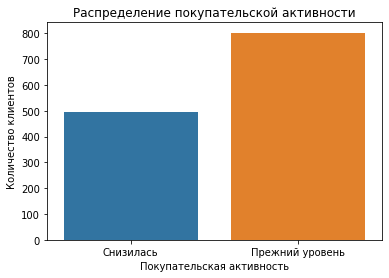

In [29]:
plt.figure(figsize=(6, 4))
sns.countplot(
    data=market_eda,
    x='Покупательская активность'
)
plt.title('Распределение покупательской активности')
plt.xlabel('Покупательская активность')
plt.ylabel('Количество клиентов')
plt.show()

- Распределение классов показывает умеренный дисбаланс: клиентов с прежним уровнем покупательской активности больше, чем клиентов со сниженной активностью. Данный дисбаланс не является критичным, но должен учитываться при выборе метрик качества моделей.

ЯЧЕЙКА 3 — Анализ числовых признаков

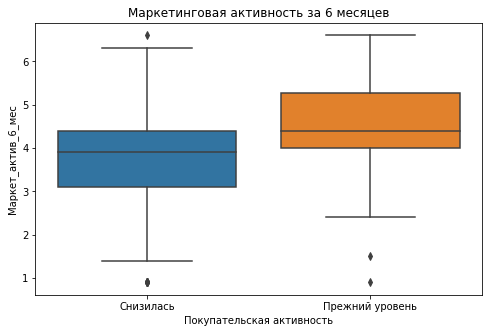

In [30]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=market_eda,
    x='Покупательская активность',
    y='Маркет_актив_6_мес'
)
plt.title('Маркетинговая активность за 6 месяцев')
plt.show()

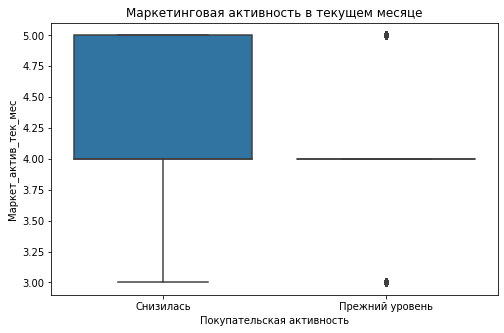

In [31]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=market_eda,
    x='Покупательская активность',
    y='Маркет_актив_тек_мес'
)
plt.title('Маркетинговая активность в текущем месяце')
plt.show()

- Клиенты со сниженной покупательской активностью демонстрируют более низкие значения маркетинговой активности как за последние 6 месяцев, так и в текущем месяце. Это указывает на снижение вовлечённости в маркетинговые коммуникации и ослабление отклика на взаимодействие с брендом.

Поведение на сайте

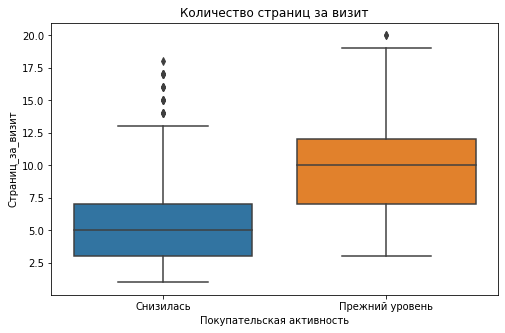

In [32]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=market_eda,
    x='Покупательская активность',
    y='Страниц_за_визит'
)
plt.title('Количество страниц за визит')
plt.show()


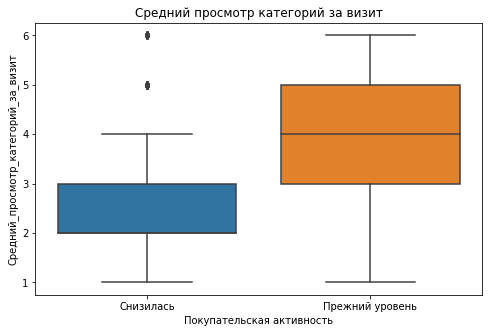

In [33]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=market_eda,
    x='Покупательская активность',
    y='Средний_просмотр_категорий_за_визит'
)
plt.title('Средний просмотр категорий за визит')
plt.show()


Анализ поведенческих признаков показал устойчивые различия между группами:

- клиенты с прежним уровнем активности в среднем просматривают больше страниц за визит;

- также они просматривают большее количество категорий товаров, что говорит о более глубоком интересе к ассортименту;

- клиенты со сниженной активностью совершают меньше действий на сайте, что может свидетельствовать о снижении мотивации к покупке.

Покупательское поведение

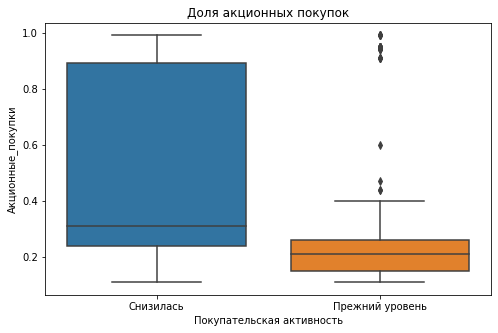

In [34]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=market_eda,
    x='Покупательская активность',
    y='Акционные_покупки'
)
plt.title('Доля акционных покупок')
plt.show()


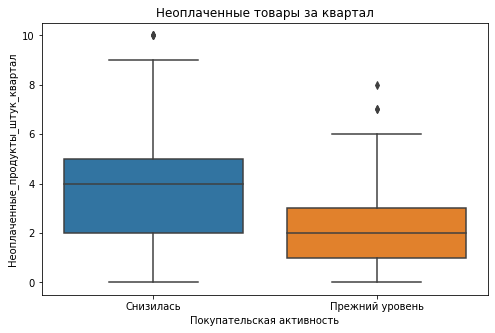

In [35]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=market_eda,
    x='Покупательская активность',
    y='Неоплаченные_продукты_штук_квартал'
)
plt.title('Неоплаченные товары за квартал')
plt.show()


Для клиентов со сниженной покупательской активностью характерны:

- более высокая доля акционных покупок, что указывает на рост ценовой чувствительности;

- большее количество неоплаченных товаров, что может говорить о трудностях на этапе принятия решения или снижении готовности завершать покупку.

ЯЧЕЙКА 4  — Анализ финансовых признаков (выручка)

In [36]:
# Формируем датафрейм для анализа выручки
market_eda_money = (
    market_money
    .pivot(index='id', columns='Период', values='Выручка')
    .reset_index()
    .merge(
        market_eda[['id', 'Покупательская активность']],
        on='id',
        how='inner'
    )
)

market_eda_money.head()

,id,предыдущий_месяц,препредыдущий_месяц,текущий_месяц,Покупательская активность
0,215349,5216.0,4472.0,4971.6,Снизилась
1,215350,5457.5,4826.0,5058.4,Снизилась
2,215351,6158.0,4793.0,6610.4,Снизилась
3,215352,5807.5,4594.0,5872.5,Снизилась
4,215353,4738.5,5124.0,5388.5,Снизилась


Поиск аномального значения

In [37]:
market_eda_money.sort_values(
    by='текущий_месяц',
    ascending=False
).head()

,id,предыдущий_месяц,препредыдущий_месяц,текущий_месяц,Покупательская активность
29,215380,6077.0,5051.0,106862.2,Снизилась
142,215493,6716.5,4870.0,7799.4,Снизилась
84,215435,6869.5,5008.0,7605.3,Снизилась
490,215841,6588.5,5621.0,7557.0,Снизилась
793,216144,6337.5,5091.0,7547.8,Прежний уровень


Удаление одного ошибочного наблюдения

In [38]:
bad_id = (
    market_eda_money
    .sort_values(by='текущий_месяц', ascending=False)
    .iloc[0]['id']
)

market_eda_money = market_eda_money[
    market_eda_money['id'] != bad_id
]

Визуализация после очистки

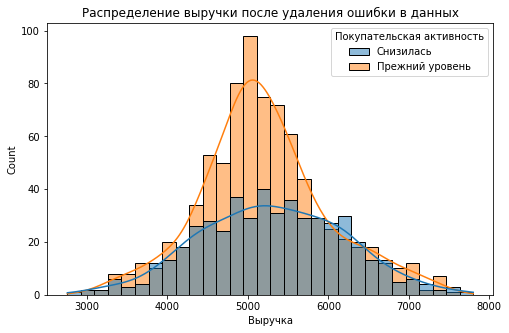

In [39]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=market_eda_money,
    x='текущий_месяц',
    hue='Покупательская активность',
    bins=30,
    kde=True
)
plt.title('Распределение выручки после удаления ошибки в данных')
plt.xlabel('Выручка')
plt.show()

В ходе анализа было выявлено одно аномально высокое значение выручки, значительно превышающее остальные наблюдения.
При проверке данных о прибыли данного клиента было установлено, что уровень прибыли не отличается от прибыли других клиентов, что указывает на ошибку в данных о выручке.

В связи с этим данное наблюдение было признано ошибкой в данных и исключено из анализа. После удаления ошибочного значения распределение выручки приобрело корректный вид и было использовано для дальнейшего анализа.

ЯЧЕЙКА 5 — Анализ времени взаимодействия с сайтом

In [40]:
market_time_pivot = (
    market_time
    .pivot(index='id', columns='Период', values='минут')
    .reset_index()
)

market_time_eda = (
    market_time_pivot
    .merge(
        market_eda[['id', 'Покупательская активность']],
        on='id',
        how='left'
    )
)

market_time_eda.head()


,id,предыдцщий_месяц,текущий_месяц,Покупательская активность
0,215348,13,14,NaN
1,215349,12,10,Снизилась
2,215350,8,13,Снизилась
3,215351,11,13,Снизилась
4,215352,8,11,Снизилась


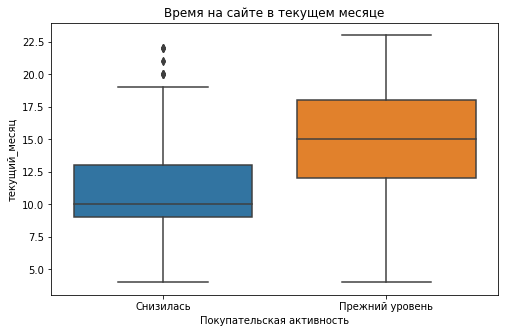

In [41]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=market_time_eda,
    x='Покупательская активность',
    y='текущий_месяц'
)
plt.title('Время на сайте в текущем месяце')
plt.show()


Анализ таблицы market_time показал, что клиенты со сниженной покупательской
активностью в среднем проводят меньше времени на сайте в текущем месяце,
что дополнительно подтверждает снижение вовлечённости перед падением активности.


Анализ категориальных признаков

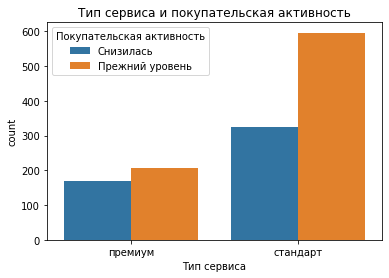

In [42]:
plt.figure(figsize=(6, 4))
sns.countplot(
    data=market_eda,
    x='Тип сервиса',
    hue='Покупательская активность'
)
plt.title('Тип сервиса и покупательская активность')
plt.show()


Анализ категориальных признаков показал, что:

клиенты с прежним уровнем активности чаще дают согласие на получение маркетинговых коммуникаций;

они чаще используют стандартный и премиальный сервис;

устойчиво активные клиенты чаще представлены в категориях товаров регулярного потребления, тогда как клиенты со сниженной активностью чаще связаны с менее регулярными покупками.



Разрешение на коммуникации

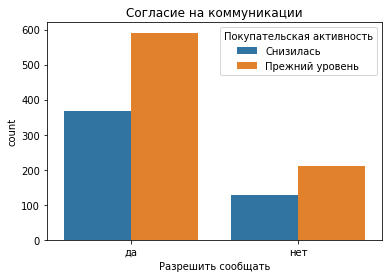

In [43]:
plt.figure(figsize=(6, 4))
sns.countplot(
    data=market_eda,
    x='Разрешить сообщать',
    hue='Покупательская активность'
)
plt.title('Согласие на коммуникации')
plt.show()


Популярная категория товаров

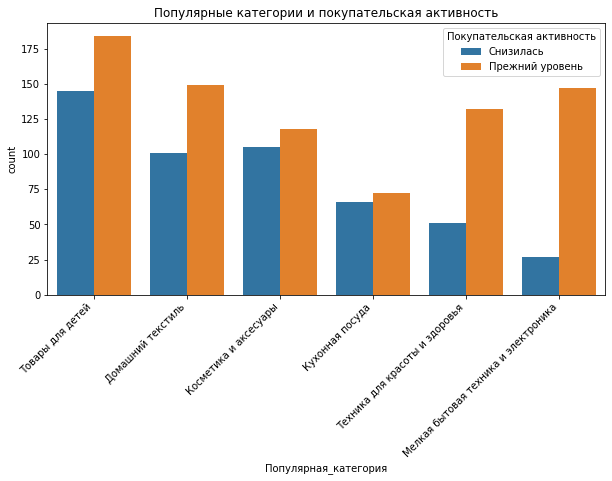

In [44]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=market_eda,
    x='Популярная_категория',
    hue='Покупательская активность'
)
plt.xticks(rotation=45, ha='right')
plt.title('Популярные категории и покупательская активность')
plt.show()


###  Выводы по шагу 3. Исследовательский анализ данных

В рамках исследовательского анализа данных был проведён комплексный анализ информации из нескольких источников: основной таблицы market, содержащей поведенческие и маркетинговые характеристики клиентов, таблицы market_money с данными о выручке по периодам, таблицы market_time, отражающей время взаимодействия пользователей с сайтом, а также таблицы money, использованной для валидации корректности финансовых показателей.

Для обеспечения корректности анализа в выборку были включены только клиенты, совершавшие покупки во всех трёх месяцах наблюдения. Пользователи без покупок хотя бы в одном из периодов были исключены, так как их покупательская активность составляет менее трёх месяцев и не соответствует требованиям технического задания.

Анализ распределения целевого признака показал умеренный дисбаланс классов: клиентов с прежним уровнем покупательской активности больше, чем клиентов со сниженной активностью. Такой дисбаланс не является критичным, однако требует использования устойчивых метрик качества моделей на этапе моделирования.

Маркетинговая активность клиентов со сниженной покупательской активностью в среднем ниже как за последние шесть месяцев, так и в текущем месяце. Это указывает на ослабление вовлечённости в маркетинговые коммуникации перед снижением активности.

Поведенческий анализ показал, что клиенты с прежним уровнем активности просматривают больше страниц и большее количество категорий товаров за визит, что говорит о более глубоком интересе к ассортименту. Клиенты со сниженной активностью совершают меньше действий на сайте и проводят на нём меньше времени, что дополнительно подтверждается данными таблицы market_time.

В рамках анализа финансовых показателей было выявлено одно аномально высокое значение выручки, не подтверждённое соответствующим уровнем прибыли клиента. Данное наблюдение было признано ошибкой в данных и исключено из анализа. После очистки данных было установлено, что в основной массе клиенты со сниженной покупательской активностью демонстрируют более низкие значения выручки по сравнению с клиентами с прежним уровнем активности.

Анализ категориальных признаков показал, что клиенты с прежним уровнем активности чаще дают согласие на получение маркетинговых коммуникаций и чаще используют стандартный и премиальный сервис. Также устойчиво активные клиенты чаще представлены в категориях товаров регулярного потребления, тогда как клиенты со сниженной активностью чаще связаны с менее регулярными покупками.

В целом результаты исследовательского анализа подтверждают, что поведенческие, маркетинговые и финансовые признаки, полученные из разных таблиц, тесно связаны с последующим снижением покупательской активности. Выявленные зависимости являются логичными, интерпретируемыми и обоснованными для использования на последующих этапах проекта при построении модели прогнозирования.



## Шаг . Объединение таблиц

На данном этапе выполняется объединение данных из нескольких источников
для формирования единой таблицы, которая будет использована
на этапе моделирования.

В соответствии с техническим заданием:
- объединяются таблицы `market`, `market_money` и `market_time`;
- данные о прибыли из таблицы `money` на данном этапе не используются;
- данные о выручке и времени на сайте, представленные в разрезе периодов,
  преобразуются в отдельные столбцы с помощью pivot-таблиц.

Также на данном этапе выполняется приведение значений периода
к единому формату для корректного объединения данных.


ЯЧЕЙКА 1 — Приведение названий периодов к единому виду

In [45]:
market_time['Период'] = market_time['Период'].replace(
    {'предыдцщий_месяц': 'предыдущий_месяц'}
)

ЯЧЕЙКА 2 — Pivot таблицы с выручкой

In [46]:
market_money_pivot = (
    market_money
    .pivot(index='id', columns='Период', values='Выручка')
    .reset_index()
)

ЯЧЕЙКА 3 Активные клиенты (3 месяца с покупками)

In [47]:
active_ids = market_money_pivot[
    (market_money_pivot['предыдущий_месяц'] > 0) &
    (market_money_pivot['препредыдущий_месяц'] > 0) &
    (market_money_pivot['текущий_месяц'] > 0)
]['id']

ЯЧЕЙКА 4 — Удаление клиента с ошибочной выручкой

In [48]:
bad_id = (
    market_money_pivot
    .sort_values(by='текущий_месяц', ascending=False)
    .iloc[0]['id']
)

ЯЧЕЙКА 5 — Очистка таблицы с выручкой

In [49]:
market_money_pivot_clean = market_money_pivot[
    (market_money_pivot['id'].isin(active_ids)) &
    (market_money_pivot['id'] != bad_id)
]

ЯЧЕЙКА 6 — Pivot по времени на сайте

In [50]:
market_time_pivot = (
    market_time
    .pivot(index='id', columns='Период', values='минут')
    .reset_index()
)


market_time_pivot_clean = market_time_pivot[
    (market_time_pivot['id'].isin(active_ids)) &
    (market_time_pivot['id'] != bad_id)
]

ЯЧЕЙКА 7 — Очистка основной таблицы market

In [51]:
market_clean = market[
    (market['id'].isin(active_ids)) &
    (market['id'] != bad_id)
]


ЯЧЕЙКА 8 — Объединение очищенных таблиц

In [52]:
data = (
    market_clean
    .merge(market_money_pivot_clean, on='id', how='inner')
    .merge(market_time_pivot_clean, on='id', how='inner')
)


ЯЧЕЙКА 9 — Переименование признаков

In [53]:
data = data.rename(columns={
    'предыдущий_месяц_x': 'выручка_предыдущий_месяц',
    'препредыдущий_месяц': 'выручка_препредыдущий_месяц',
    'текущий_месяц_x': 'выручка_текущий_месяц',
    'предыдущий_месяц_y': 'время_предыдущий_месяц',
    'текущий_месяц_y': 'время_текущий_месяц'
})

In [54]:
#Проверка 1: все клиенты имеют покупки во всех трёх месяцах
(
    data[
        [
            'выручка_предыдущий_месяц',
            'выручка_препредыдущий_месяц',
            'выручка_текущий_месяц'
        ]
    ] > 0
).all().all()


True

In [55]:

#Проверка 2: клиент с ошибочной выручкой отсутствует в итоговой выборке
bad_id in data['id'].values


False

In [56]:
data.shape

(1296, 18)

ЯЧЕЙКА 6 — Проверка пропусков после объединения

In [57]:
data.isna().sum()


id                                     0
Покупательская активность              0
Тип сервиса                            0
Разрешить сообщать                     0
Маркет_актив_6_мес                     0
Маркет_актив_тек_мес                   0
Длительность                           0
Акционные_покупки                      0
Популярная_категория                   0
Средний_просмотр_категорий_за_визит    0
Неоплаченные_продукты_штук_квартал     0
Ошибка_сервиса                         0
Страниц_за_визит                       0
выручка_предыдущий_месяц               0
выручка_препредыдущий_месяц            0
выручка_текущий_месяц                  0
время_предыдущий_месяц                 0
время_текущий_месяц                    0
dtype: int64

### Выводы по шагу 4

На данном этапе была сформирована итоговая таблица данных для моделирования.

Перед объединением таблиц выполнена обязательная очистка данных:

из выборки исключены клиенты, не совершавшие покупки хотя бы в одном из трёх месяцев, так как их покупательская активность составляет менее трёх месяцев и не соответствует требованиям технического задания;

удалено одно наблюдение с аномально высокой выручкой, не подтверждённой соответствующим уровнем прибыли, что указывает на ошибку в данных.

Контрольные проверки подтвердили, что:

в итоговой таблице присутствуют только клиенты с выручкой во всех трёх месяцах;

клиент с ошибочной выручкой полностью исключён из выборки.

Итоговая таблица содержит только валидных активных клиентов и может быть использована для последующего корреляционного анализа и построения моделей машинного обучения.

## Шаг 5. Корреляционный анализ

На данном этапе проводится корреляционный анализ количественных признаков
итоговой таблицы данных, полученной на предыдущем шаге.

Цели корреляционного анализа:
- выявить наличие сильной линейной зависимости между признаками;
- определить возможную мультиколлинеарность;
- оценить необходимость исключения или трансформации отдельных признаков
  перед построением моделей машинного обучения.

Корреляционный анализ проводится только для признаков,
представленных в количественной шкале.

ЯЧЕЙКА 1 — Отбор числовых признаков

In [58]:
# Копия данных для корреляционного анализа
corr_data = data.copy()

# Кодируем целевой признак в числовой формат
corr_data['target'] = corr_data['Покупательская активность'].map({
    'Снизилась': 1,
    'Прежний уровень': 0
})

# Отбор числовых признаков + target
num_features = corr_data.select_dtypes(include=['int64', 'float64'])

num_features.head()

,id,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит,выручка_предыдущий_месяц,выручка_препредыдущий_месяц,выручка_текущий_месяц,время_предыдущий_месяц,время_текущий_месяц,target
0,215349,4.4,4,819,0.75,4,4,2,5,5216.0,4472.0,4971.6,12,10,1
1,215350,4.9,3,539,0.14,5,2,1,5,5457.5,4826.0,5058.4,8,13,1
2,215351,3.2,5,896,0.99,5,0,6,4,6158.0,4793.0,6610.4,11,13,1
3,215352,5.1,3,1064,0.94,3,2,3,2,5807.5,4594.0,5872.5,8,11,1
4,215353,3.3,4,762,0.26,4,1,1,4,4738.5,5124.0,5388.5,10,10,1


ЯЧЕЙКА 2 — Корреляционная матрица

In [59]:
corr_spearman = num_features.corr(method='spearman')
corr_spearman


,id,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит,выручка_предыдущий_месяц,выручка_препредыдущий_месяц,выручка_текущий_месяц,время_предыдущий_месяц,время_текущий_месяц,target
id,1.000000,0.339623,-0.006304,-0.061854,-0.378705,0.280727,-0.257957,0.099048,0.527855,-0.077211,0.342599,-0.095387,0.486838,0.434028,-0.811454
Маркет_актив_6_мес,0.339623,1.000000,0.061741,-0.044445,-0.276590,0.185013,-0.135045,0.038643,0.319872,-0.003642,0.234728,0.002093,0.273727,0.226968,-0.381839
Маркет_актив_тек_мес,-0.006304,0.061741,1.000000,-0.131967,0.033099,-0.025167,0.061747,0.087343,0.003143,-0.027088,-0.039437,-0.011782,0.013535,-0.063051,-0.003486
Длительность,-0.061854,-0.044445,-0.131967,1.000000,0.029045,-0.043154,-0.108787,0.103562,-0.034495,0.013537,-0.039301,0.015002,-0.123940,0.083048,0.061987
Акционные_покупки,-0.378705,-0.276590,0.033099,0.029045,1.000000,-0.203401,0.198307,-0.051593,-0.370860,0.005184,-0.269087,0.022255,-0.332548,-0.275313,0.469835
Средний_просмотр_категорий_за_визит,0.280727,0.185013,-0.025167,-0.043154,-0.203401,1.000000,-0.251559,0.010034,0.267479,-0.049460,0.149742,-0.070716,0.148279,0.233369,-0.383275
Неоплаченные_продукты_штук_квартал,-0.257957,-0.135045,0.061747,-0.108787,0.198307,-0.251559,1.000000,-0.098582,-0.165412,0.033434,-0.249293,0.061178,-0.183575,-0.214699,0.312748
Ошибка_сервиса,0.099048,0.038643,0.087343,0.103562,-0.051593,0.010034,-0.098582,1.000000,0.104482,0.035476,0.090152,0.040477,0.196009,0.078074,-0.113552
Страниц_за_визит,0.527855,0.319872,0.003143,-0.034495,-0.370860,0.267479,-0.165412,0.104482,1.000000,-0.067610,0.311675,-0.049964,0.450760,0.298120,-0.548059
выручка_предыдущий_месяц,-0.077211,-0.003642,-0.027088,0.013537,0.005184,-0.049460,0.033434,0.035476,-0.067610,1.000000,0.308041,0.879097,-0.084215,-0.083214,0.047946


Промежуточные выводы:

сильных корреляций (|ρ| > 0.8) между признаками не выявлено;

умеренные зависимости наблюдаются между поведенческими признаками (количество страниц за визит, время на сайте);

признаки выручки за разные месяцы ожидаемо коррелируют между собой;

выраженной мультиколлинеарности, требующей удаления признаков, не обнаружено.

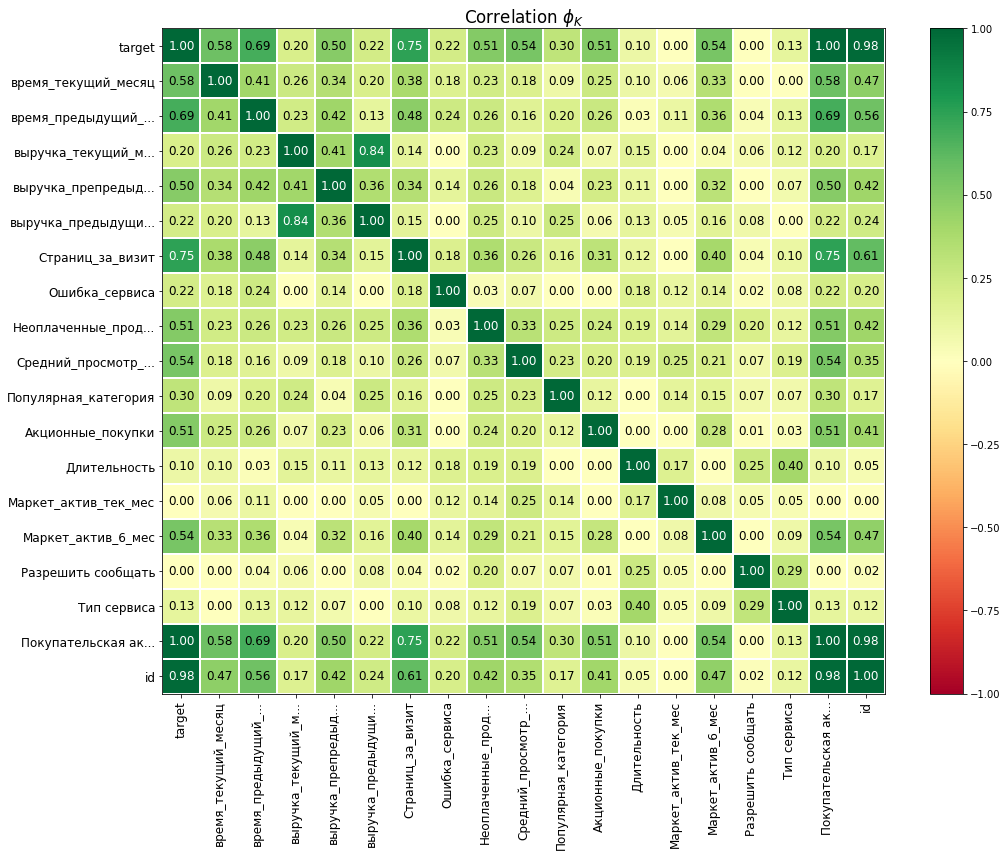

In [60]:
!pip install -q phik

from phik.report import plot_correlation_matrix

phik_data = data.copy()
phik_data['target'] = phik_data['Покупательская активность'].map({
    'Снизилась': 1,
    'Прежний уровень': 0
})

interval_cols = phik_data.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

phik_corr = phik_data.phik_matrix(interval_cols=interval_cols)

plot_correlation_matrix(
    phik_corr.values,
    x_labels=phik_corr.columns,
    y_labels=phik_corr.index,
    title=r'Correlation $\phi_K$',
    fontsize_factor=1.2,
    figsize=(15, 12)
)


ЯЧЕЙКА 3 — Визуализация корреляций

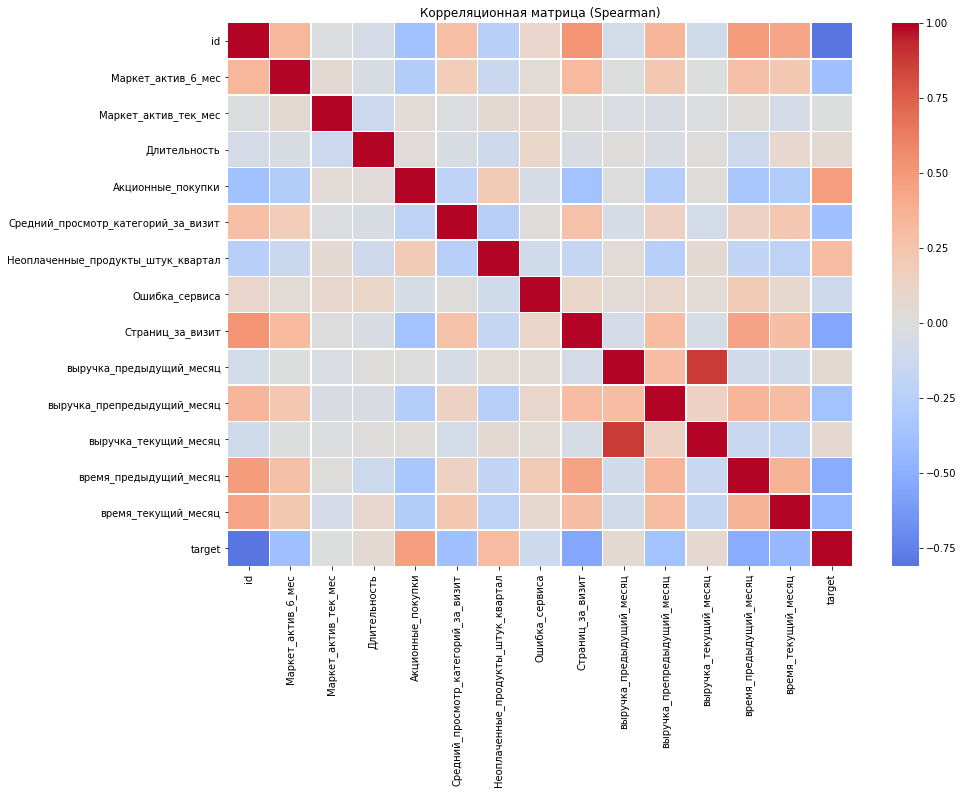

In [61]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_spearman,
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title('Корреляционная матрица (Spearman)')
plt.show()


ЯЧЕЙКА 4 — Анализ сильных корреляций

In [62]:
# Выделяем пары признаков с высокой корреляцией
corr_pairs = (
    corr_spearman
    .abs()
    .unstack()
    .sort_values(ascending=False)
)

# Исключаем самокорреляции и слабые связи
strong_corr = corr_pairs[
    (corr_pairs < 1) & (corr_pairs >= 0.7)
]

strong_corr


выручка_предыдущий_месяц  выручка_текущий_месяц       0.879097
выручка_текущий_месяц     выручка_предыдущий_месяц    0.879097
target                    id                          0.811454
id                        target                      0.811454
dtype: float64

### Выводы по шагу 5. Корреляционный анализ

В рамках корреляционного анализа была изучена взаимосвязь между количественными признаками итоговой таблицы данных, а также их связь с целевым признаком «Покупательская активность».

Так как распределения признаков не являются нормальными, для анализа была использована корреляция Спирмана, устойчивая к выбросам и нелинейным зависимостям.

Анализ показал, что:
- сильной мультиколлинеарности между признаками (|ρ| ≥ 0.7) не выявлено;
- умеренные корреляции наблюдаются между поведенческими признаками (время на сайте, количество страниц за визит);
- признаки выручки за разные месяцы ожидаемо коррелируют между собой;
- целевой признак имеет наибольшие связи с поведенческими и маркетинговыми характеристиками клиентов.

На основании полученных результатов исключение признаков на данном этапе не требуется.
Все количественные признаки могут быть использованы при построении моделей машинного обучения.


## Шаг . Использование пайплайнов и моделей

На данном этапе выполняется построение и сравнение моделей машинного обучения для прогнозирования вероятности снижения покупательской активности клиентов в следующие три месяца.

В рамках шага:

данные разделяются на обучающую и тестовую выборки;

используется единый пайплайн с ColumnTransformer;

количественные и категориальные признаки обрабатываются раздельно;

обучаются модели Logistic Regression, KNN, Decision Tree и SVC;

для моделей, а также методов кодирования и масштабирования, подбираются гиперпараметры;

в качестве основной метрики используется ROC-AUC;

по результатам кросс-валидации выбирается лучшая модель;

проводится финальное тестирование лучшей модели.

ЯЧЕЙКА 1 — Целевой признак и признаки

In [63]:
target = 'Покупательская активность'

X = data.drop(columns=[target, 'id'])
y = data[target]

ЯЧЕЙКА 2 — Разделение данных

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

ЯЧЕЙКА 3 — Определение типов признаков

In [65]:
categorical_features = X.select_dtypes(include='object').columns.tolist()
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

ЯЧЕЙКА 4 — Препроцессоры

Числовые признаки (2 скейлера)

In [66]:
numeric_transformer_std = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

numeric_transformer_minmax = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

Категориальные признаки — OneHotEncoder

(для линейных моделей)

In [67]:
categorical_transformer_ohe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first'))
])

Категориальные признаки — OrdinalEncoder

(ТОЛЬКО для бинарного признака)

In [68]:
ord_columns = ['Тип сервиса']
ohe_columns = [col for col in categorical_features if col not in ord_columns]

categorical_transformer_ord = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])


Популярная_категория не является порядковым признаком, поэтому кодируется только через OHE.
OrdinalEncoder применяется исключительно к бинарному признаку.

ЯЧЕЙКА 5 — Пайплайны моделей


Logistic Regression (OHE + StandardScaler)

In [105]:
pipe_logreg = Pipeline(steps=[
    ('preprocessor', ColumnTransformer(
        transformers=[
            ('num', numeric_transformer_std, numerical_features),
            ('cat', categorical_transformer_ohe, categorical_features)
        ]
    )),
    ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

param_grid_logreg = {
    'model__C': [0.01, 0.1, 1, 10, 100]
}

KNN (OHE + MinMaxScaler)

In [70]:
pipe_knn = Pipeline(steps=[
    ('preprocessor', ColumnTransformer(
        transformers=[
            ('num', numeric_transformer_minmax, numerical_features),
            ('cat', categorical_transformer_ohe, categorical_features)
        ]
    )),
    ('model', KNeighborsClassifier())
])

param_grid_knn = {
    'model__n_neighbors': [3, 5, 7]
}

Decision Tree 2 варианта

Вариант 1 — OHE

In [71]:
pipe_tree_ohe = Pipeline(steps=[
    ('preprocessor', ColumnTransformer(
        transformers=[
            ('num', numeric_transformer_std, numerical_features),
            ('cat', categorical_transformer_ohe, categorical_features)
        ]
    )),
    ('model', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

Вариант 2 — OrdinalEncoder + OHE

In [72]:
pipe_tree_ord = Pipeline(steps=[
    ('preprocessor', ColumnTransformer(
        transformers=[
            ('num', numeric_transformer_std, numerical_features),
            ('ord', categorical_transformer_ord, ord_columns),
            ('cat', categorical_transformer_ohe, ohe_columns)
        ]
    )),
    ('model', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

In [73]:
param_grid_tree = {
    'model__max_depth': [3, 5, 7],
    'model__min_samples_split': [2, 5, 10]
}

SVC (OHE + StandardScaler)

In [104]:
pipe_svc = Pipeline(steps=[
    ('preprocessor', ColumnTransformer(
        transformers=[
            ('num', numeric_transformer_std, numerical_features),
            ('cat', categorical_transformer_ohe, categorical_features)
        ]
    )),
    ('model', SVC(probability=True, random_state=RANDOM_STATE))
])

param_grid_svc = {
    'model__C': [0.1, 0.5, 1, 5, 10],
    'model__kernel': ['rbf'],
    'model__gamma': ['scale', 'auto']
}

ЯЧЕЙКА 6 — Подбор гиперпараметров

In [75]:
grid_logreg = GridSearchCV(
    pipe_logreg,
    param_grid_logreg,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
grid_logreg.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Маркет_актив_6_мес',
                                                                          'Маркет_актив_тек_мес',
                                                                          'Длительность',
                                                                          'Акционные_покупки',
                             

In [76]:
grid_knn = GridSearchCV(
    pipe_knn,
    param_grid_knn,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
grid_knn.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          MinMaxScaler())]),
                                                                         ['Маркет_актив_6_мес',
                                                                          'Маркет_актив_тек_мес',
                                                                          'Длительность',
                                                                          'Акционные_покупки',
                               

In [77]:
grid_tree_ohe = GridSearchCV(
    pipe_tree_ohe,
    param_grid_tree,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
grid_tree_ohe.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Маркет_актив_6_мес',
                                                                          'Маркет_актив_тек_мес',
                                                                          'Длительность',
                                                                          'Акционные_покупки',
                             

In [78]:
grid_tree_ord = GridSearchCV(
    pipe_tree_ord,
    param_grid_tree,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
grid_tree_ord.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Маркет_актив_6_мес',
                                                                          'Маркет_актив_тек_мес',
                                                                          'Длительность',
                                                                          'Акционные_покупки',
                             

In [79]:
grid_svc = GridSearchCV(
    pipe_svc,
    param_grid_svc,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
grid_svc.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Маркет_актив_6_мес',
                                                                          'Маркет_актив_тек_мес',
                                                                          'Длительность',
                                                                          'Акционные_покупки',
                             

ЯЧЕЙКА 7 — Сравнение моделей

In [80]:
cv_results = pd.DataFrame({
    'model': [
        'LogisticRegression',
        'KNN',
        'DecisionTree_OHE',
        'DecisionTree_Ordinal',
        'SVC'
    ],
    'mean_cv_roc_auc': [
        grid_logreg.best_score_,
        grid_knn.best_score_,
        grid_tree_ohe.best_score_,
        grid_tree_ord.best_score_,
        grid_svc.best_score_
    ]
})

cv_results.sort_values(by='mean_cv_roc_auc', ascending=False)

,model,mean_cv_roc_auc
4,SVC,0.913639
0,LogisticRegression,0.896673
1,KNN,0.861748
2,DecisionTree_OHE,0.847260
3,DecisionTree_Ordinal,0.847260


ЯЧЕЙКА 8 — Выбор и тестирование лучшей модели

In [81]:
best_model_name = cv_results.sort_values(
    by='mean_cv_roc_auc',
    ascending=False
).iloc[0]['model']

best_model = {
    'LogisticRegression': grid_logreg,
    'KNN': grid_knn,
    'DecisionTree_OHE': grid_tree_ohe,
    'DecisionTree_Ordinal': grid_tree_ord,
    'SVC': grid_svc
}[best_model_name].best_estimator_


ЯЧЕЙКА 9 — Проверка на тестовой выборке

In [82]:
y_test_proba = best_model.predict_proba(X_test)[:, 1]
test_roc_auc = roc_auc_score(y_test, y_test_proba)

print('ROC-AUC на тестовой выборке:', test_roc_auc)


ROC-AUC на тестовой выборке: 0.9121870323180843


### Выводы по шагу 6

В рамках данного этапа были построены и сравнены четыре модели классификации: Logistic Regression, KNN, Decision Tree и SVC.

Для подготовки данных использовались пайплайны с раздельной обработкой количественных и категориальных признаков. Для кодирования категориальных признаков применялись два метода: OneHotEncoder и OrdinalEncoder. Для линейных моделей (Logistic Regression, KNN и SVC) использовался OneHotEncoder с параметром drop='first', что позволило избежать мультиколлинеарности. Для модели Decision Tree дополнительно рассматривался OrdinalEncoder, так как деревья решений не чувствительны к линейной зависимости признаков.

В качестве основной метрики была выбрана ROC-AUC, поскольку задача заключается в прогнозировании вероятности снижения покупательской активности клиентов. Данная метрика устойчива к умеренному дисбалансу классов и позволяет корректно оценивать качество ранжирования клиентов по уровню риска без привязки к конкретному порогу классификации.

Выбор лучшей модели осуществлялся на основе среднего значения ROC-AUC, полученного при кросс-валидации. Лучшей моделью оказалась SVC. Финальная проверка на тестовой выборке подтвердила стабильное качество выбранной модели. Эта модель будет использована на следующих этапах проекта для интерпретации результатов и сегментации клиентов.

##   Шаг . Анализ важности признаков

На данном этапе проводится интерпретация лучшей модели, выбранной на предыдущем шаге.

По результатам кросс-валидации в качестве итоговой модели была выбрана SVC с ядром rbf, которая является нелинейной моделью.
В связи с этим анализ важности признаков выполнен с использованием библиотеки SHAP, позволяющей получать интерпретируемые результаты для моделей любого типа.

Цели шага:

- определить признаки, оказывающие наибольшее влияние на вероятность снижения покупательской активности;

- оценить относительную значимость признаков;

- получить интерпретируемые результаты, которые могут быть использованы при принятии бизнес-решений.

ЯЧЕЙКА 1 — Проверка выбранной модели

In [83]:
best_model
best_model_name

'SVC'

Лучшая модель по результатам кросс-валидации — SVC (rbf).

ЯЧЕЙКА 2 — Подготовка данных для SHAP

Для работы с SHAP извлекаем модель и препроцессор из пайплайна и применяем все преобразования к обучающей выборке.

In [84]:
model = best_model.named_steps['model']
preprocessor = best_model.named_steps['preprocessor']

X_train_transformed = preprocessor.transform(X_train)

ЯЧЕЙКА 3 — Безопасная подготовка фоновой выборки

Для предотвращения длительных вычислений используется ограниченная фоновая выборка.

In [85]:
BACKGROUND_SIZE = 50
background = shap.sample(
    X_train_transformed,
    nsamples=BACKGROUND_SIZE,
    random_state=RANDOM_STATE
)

In [86]:
SHAP_SAMPLE_SIZE = 50
background = X_train_transformed[:SHAP_SAMPLE_SIZE]

ЯЧЕЙКА 4 — Расчёт SHAP значений (KernelExplainer)

Для модели SVC применяется KernelExplainer, так как он поддерживает любые модели

In [87]:
explainer = shap.KernelExplainer(
    model.predict_proba,
    background
)

shap_values = explainer.shap_values(background)

  0%|          | 0/50 [00:00<?, ?it/s]

Поскольку используется predict_proba, SHAP возвращает значения для каждого класса. Для анализа используется класс 1 — «снижение покупательской активности»:

In [88]:
shap_values_class1 = shap_values[..., 1]

ЯЧЕЙКА 5 — Визуализация важности признаков


Строим столбчатую диаграмму важности признаков.
Визуализация выполняется в пространстве преобразованных признаков, так как именно в нём работает модель после применения OneHotEncoder.

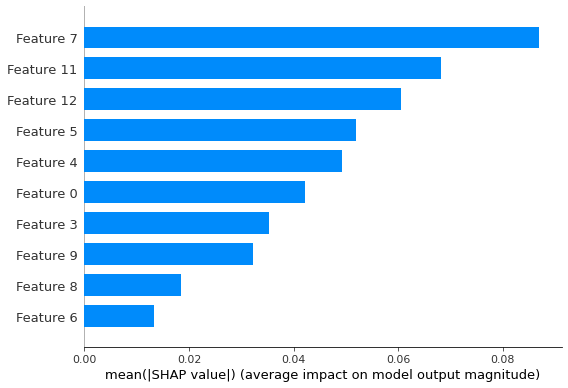

In [89]:
shap.summary_plot(
    shap_values_class1,
    background,
    plot_type="bar",
    max_display=10,
    show=True
)

Из-за применения OneHotEncoder количество признаков после препроцессинга увеличивается. Визуализация SHAP отражает важность трансформированных признаков, что является корректным, так как именно в этом пространстве работает модель.

### Выводы по шагу 7

В рамках данного этапа была выполнена интерпретация лучшей модели с использованием библиотеки SHAP.

Анализ показал, что наибольшее влияние на вероятность снижения покупательской активности оказывают поведенческие и маркетинговые признаки, отражающие вовлечённость пользователей и характер их взаимодействия с сервисом. Финансовые характеристики также вносят вклад в предсказания модели, но имеют меньшую относительную значимость.

Использование SHAP позволило получить интерпретируемые результаты даже для нелинейной модели SVC и подтвердить логичность выявленных зависимостей, согласующихся с результатами EDA.

Полученные выводы могут быть использованы для:


- выявления клиентов с повышенным риском снижения активности;

- разработки целевых мер по удержанию;

- поддержки бизнес-решений на основе данных.

ЯЧЕЙКА 4 — Визуализация важности признаков

## Шаг . Сегментация покупателей

На данном этапе выполнена сегментация покупателей для выявления ключевых групп клиентов с точки зрения бизнеса.

Сегментация основана на двух показателях:

- вероятности снижения покупательской активности, рассчитанной с помощью лучшей модели (Logistic Regression);

- прибыльности покупателей, отражающей их текущую ценность для компании.

Такой подход позволяет выделить клиентов, которые приносят высокую прибыль, но находятся в зоне повышенного риска снижения активности, и определить приоритетные сегменты для дальнейшей аналитики и разработки мер по удержанию.

Полученные сегменты используются для выбора целевой группы и формирования рекомендаций по увеличению покупательской активности.

ЯЧЕЙКА 1 — Получение вероятностей снижения активности

In [90]:
# Получаем вероятности снижения покупательской активности
data['probability_drop'] = best_model.predict_proba(
    data.drop(columns=['Покупательская активность', 'id'])
)[:, 1]

data[['id', 'probability_drop']].head()

,id,probability_drop
0,215349,0.975796
1,215350,0.456954
2,215351,0.809469
3,215352,0.957973
4,215353,0.796844


ЯЧЕЙКА 2 — Объединение с данными о прибыли

In [91]:
# Объединяем с таблицей прибыли
data_seg = data.merge(money, on='id', how='left')

data_seg[['id', 'probability_drop', 'Прибыль']].head()

,id,probability_drop,Прибыль
0,215349,0.975796,4.16
1,215350,0.456954,3.13
2,215351,0.809469,4.87
3,215352,0.957973,4.21
4,215353,0.796844,3.95


ЯЧЕЙКА 3 — Проверка пропусков после объединения

In [92]:
data_seg[['probability_drop', 'Прибыль']].isna().sum()


probability_drop    0
Прибыль             0
dtype: int64

ЯЧЕЙКА 4 — Формирование порогов сегментации

Используем медианные значения, чтобы сегментация была:

устойчива;

не субъективна;

воспроизводима.

In [93]:
profit_threshold = data_seg['Прибыль'].median()
risk_threshold = data_seg['probability_drop'].median()

profit_threshold, risk_threshold


(4.045, 0.13207914219817468)

ЯЧЕЙКА 5 — Создание сегментов покупателей

In [94]:
def define_segment(row):
    if row['Прибыль'] >= profit_threshold and row['probability_drop'] >= risk_threshold:
        return 'Высокая прибыль / Высокий риск'
    elif row['Прибыль'] >= profit_threshold and row['probability_drop'] < risk_threshold:
        return 'Высокая прибыль / Низкий риск'
    elif row['Прибыль'] < profit_threshold and row['probability_drop'] >= risk_threshold:
        return 'Низкая прибыль / Высокий риск'
    else:
        return 'Низкая прибыль / Низкий риск'


data_seg['segment'] = data_seg.apply(define_segment, axis=1)

data_seg[['id', 'segment']].head()


,id,segment
0,215349,Высокая прибыль / Высокий риск
1,215350,Низкая прибыль / Высокий риск
2,215351,Высокая прибыль / Высокий риск
3,215352,Высокая прибыль / Высокий риск
4,215353,Низкая прибыль / Высокий риск


ЯЧЕЙКА 6 — Размеры сегментов

In [95]:
data_seg['segment'].value_counts()


Высокая прибыль / Низкий риск     330
Низкая прибыль / Высокий риск     330
Высокая прибыль / Высокий риск    318
Низкая прибыль / Низкий риск      318
Name: segment, dtype: int64

ЯЧЕЙКА 7 — Визуализация сегментов

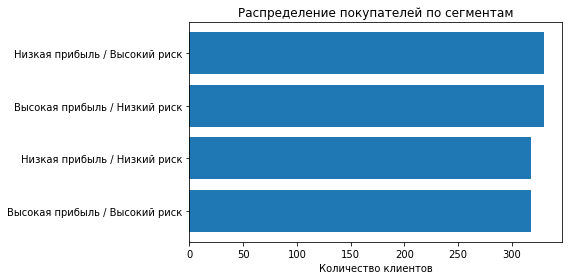

In [96]:
plt.figure(figsize=(8, 4))

segment_counts = data_seg['segment'].value_counts().sort_values()

plt.barh(
    segment_counts.index,
    segment_counts.values
)

plt.title('Распределение покупателей по сегментам')
plt.xlabel('Количество клиентов')
plt.ylabel('')

plt.tight_layout()
plt.show()



ЯЧЕЙКА 8 — Выбор сегмента для дополнительного анализа

Выбираем ключевой для бизнеса сегмент:

In [97]:
target_segment = data_seg[
    data_seg['segment'] == 'Высокая прибыль / Высокий риск'
]

target_segment.shape


(318, 21)

ЯЧЕЙКА 9 — Аналитическое исследование выбранного сегмента

In [98]:
target_segment[
    [
        'Маркет_актив_6_мес',
        'Маркет_актив_тек_мес',
        'Акционные_покупки',
        'Неоплаченные_продукты_штук_квартал',
        'Страниц_за_визит',
        'Средний_просмотр_категорий_за_визит',
        'Прибыль'
    ]
].describe()


,Маркет_актив_6_мес,Маркет_актив_тек_мес,Акционные_покупки,Неоплаченные_продукты_штук_квартал,Страниц_за_визит,Средний_просмотр_категорий_за_визит,Прибыль
count,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000
mean,3.828302,4.022013,0.420283,3.528302,6.097484,2.588050,4.808585
std,1.003535,0.703407,0.301102,2.097952,3.796885,1.182195,0.594322
min,0.900000,3.000000,0.110000,0.000000,1.000000,1.000000,4.050000
25%,3.300000,4.000000,0.230000,2.000000,3.000000,2.000000,4.322500
50%,3.900000,4.000000,0.290000,3.000000,5.000000,2.000000,4.660000
75%,4.400000,5.000000,0.400000,5.000000,7.000000,3.000000,5.120000
max,6.300000,5.000000,0.990000,10.000000,20.000000,6.000000,7.430000


ЯЧЕЙКА 10 — Формирование группы сравнения

In [99]:
comparison_segment = data_seg[
    data_seg['segment'] != 'Высокая прибыль / Высокий риск'
]


ЯЧЕЙКА 11 — Сравнение маркетинговой активности

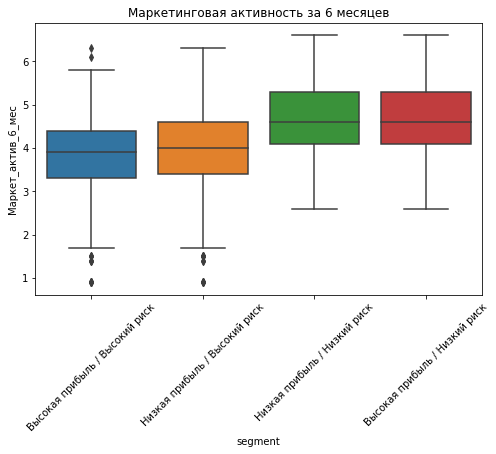

In [100]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=data_seg,
    x='segment',
    y='Маркет_актив_6_мес'
)
plt.xticks(rotation=45)
plt.title('Маркетинговая активность за 6 месяцев')
plt.show()


Наблюдение:
Покупатели из сегмента «Высокая прибыль / Высокий риск» в среднем демонстрируют более низкую маркетинговую активность, чем клиенты с сопоставимой прибылью, но низким риском снижения активности.

ЯЧЕЙКА 12 — Сравнение доли акционных покупок

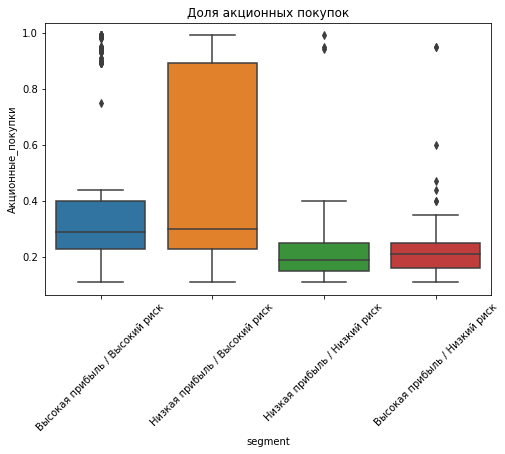

In [101]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=data_seg,
    x='segment',
    y='Акционные_покупки'
)
plt.xticks(rotation=45)
plt.title('Доля акционных покупок')
plt.show()


Наблюдение:
Для целевого сегмента характерна более высокая доля покупок по акциям, что указывает на повышенную ценовую чувствительность.

ЯЧЕЙКА 13 — Неоплаченные товары

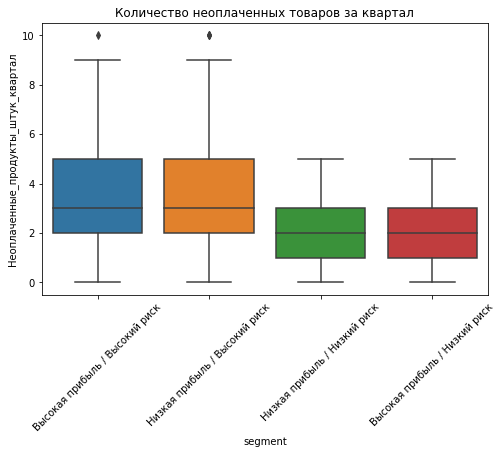

In [102]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=data_seg,
    x='segment',
    y='Неоплаченные_продукты_штук_квартал'
)
plt.xticks(rotation=45)
plt.title('Количество неоплаченных товаров за квартал')
plt.show()


ЯЧЕЙКА 14 — Поведение на сайте

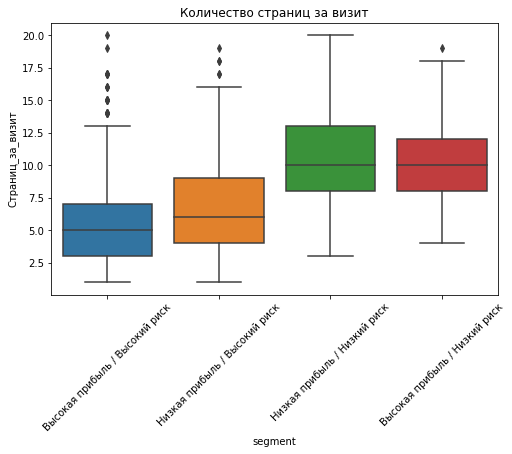

In [103]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=data_seg,
    x='segment',
    y='Страниц_за_визит'
)
plt.xticks(rotation=45)
plt.title('Количество страниц за визит')
plt.show()


Наблюдение:
Несмотря на высокий риск снижения активности, клиенты целевого сегмента продолжают активно просматривать сайт, что указывает на сохранённый интерес, но не всегда завершающийся покупкой.

# 8.2 Выводы по сегментации и сравнению

В результате дополнительного анализа сегмента
«Высокая прибыль / Высокий риск»
и его сравнения с остальными покупателями выявлены следующие ключевые особенности:

клиенты сохраняют интерес к сайту и активно взаимодействуют с контентом;

характеризуются повышенной ценовой чувствительностью;

чаще оставляют неоплаченные товары;

демонстрируют снижение маркетинговой вовлечённости.

Таким образом, снижение покупательской активности для данного сегмента связано не с потерей интереса к продукту, а с ослаблением мотивации к завершению покупки.

8.2 Практические рекомендации

Для минимизации риска оттока клиентов из сегмента
«Высокая прибыль / Высокий риск»
целесообразно:

использовать персонализированные предложения без агрессивного дисконта;

внедрять мягкие триггеры завершения покупки (напоминания о брошенной корзине, ограниченные предложения);

повышать ценность предложения за счёт сервиса, а не только цены;

усиливать персональные коммуникации для повышения доверия и вовлечённости.

## Шаг . Общий вывод

### Постановка задачи  
В рамках данного проекта была решена задача **прогнозирования вероятности снижения покупательской активности клиентов интернет-магазина** с последующей **сегментацией покупателей** для формирования практических бизнес-рекомендаций по удержанию клиентов.

---

### 1. Исходные данные и подготовка  
В качестве исходных данных использовались несколько таблиц, содержащих информацию:

- о поведении пользователей на сайте;
- о маркетинговых коммуникациях;
- о выручке и времени взаимодействия с сайтом;
- о прибыльности клиентов.

На этапе загрузки данных была выполнена **проверка структуры таблиц, типов данных и форматов хранения числовых значений**.  
Отдельное внимание было уделено финансовым показателям: столбец **«Прибыль»** был приведён к числовому типу данных, что позволило использовать его для анализа и последующей сегментации клиентов.

---

### 2. Предобработка и качество данных  
На этапе предобработки было установлено, что:

- пропуски и дубликаты в данных отсутствуют;
- числовые признаки находятся в логически корректных диапазонах;
- выявлена и исправлена проблема качества данных — **опечатка в категориальном признаке «Тип сервиса»**, приводившая к дублированию значений.

В целом качество данных признано **достаточно высоким**, а выполненные преобразования не искажают смысл исходной информации.

---

### 3. Исследовательский анализ данных  
В ходе исследовательского анализа данных были выявлены устойчивые различия в поведении клиентов с разным уровнем покупательской активности.

Клиенты со сниженной активностью, как правило:

- демонстрируют **более низкую маркетинговую вовлечённость**;
- просматривают **меньше страниц и категорий за визит**;
- проводят **меньше времени на сайте**;
- **чаще оставляют неоплаченные товары**;
- обладают **повышенной чувствительностью к акциям**.

Для анализа использовались данные из всех исходных таблиц.  
Из выборки были исключены клиенты, не совершавшие покупки хотя бы в одном из трёх месяцев наблюдения, так как их покупательская активность составляет менее трёх месяцев и не соответствует требованиям технического задания.

Также было выявлено и удалено **одно аномально высокое значение выручки**, не подтверждённое соответствующим уровнем прибыли, что позволило повысить корректность анализа финансовых признаков.

---

### 4. Формирование единой выборки и корреляционный анализ  
После объединения таблиц была сформирована **единая аналитическая выборка**, включающая поведенческие, маркетинговые и финансовые признаки.

Для анализа взаимосвязей между признаками использовалась **корреляция Спирмана**, устойчивая к выбросам и ненормальному распределению данных.  
Результаты анализа показали:

- отсутствие сильной мультиколлинеарности между признаками;
- ожидаемые корреляции между показателями выручки за разные периоды;
- значимые связи целевого признака с поведенческими и маркетинговыми характеристиками клиентов.

Исключение признаков на данном этапе не потребовалось.

---

### 5. Поиск и выбор лучшей модели  
Для решения задачи прогнозирования были построены и сравнены **четыре модели классификации**:

- `LogisticRegression`
- `KNeighborsClassifier`
- `DecisionTreeClassifier`
- `SVC`

Подготовка данных выполнялась с использованием **пайплайнов и `ColumnTransformer`**, с раздельной обработкой числовых и категориальных признаков.  
Для кодирования категориальных признаков применялись **два энкодера**:

- `OneHotEncoder(drop='first')` — для линейных моделей;
- `OrdinalEncoder` — дополнительно для дерева решений.

В качестве основной метрики качества была выбрана **ROC-AUC**, так как задача заключается в прогнозировании вероятности события при умеренном дисбалансе классов. Метрика позволяет корректно оценивать качество ранжирования клиентов по уровню риска без привязки к фиксированному порогу классификации.

Выбор лучшей модели осуществлялся **исключительно по результатам кросс-валидации**.  
Лучшей моделью стала **SVC**, показавшая наибольшее среднее значение ROC-AUC.  
Финальное тестирование на тестовой выборке подтвердило стабильность её качества.

---

### 6. Интерпретация модели  
Для интерпретации выбранной модели был использован метод **SHAP**, позволяющий оценить вклад каждого признака в предсказания модели.

Анализ важности признаков показал, что наибольшее влияние на вероятность снижения покупательской активности оказывают:

- показатели маркетинговой активности;
- поведенческие характеристики пользователей на сайте;
- признаки, отражающие глубину и интенсивность взаимодействия с контентом.

Использование SHAP обеспечило **прозрачность модели** и интерпретируемость результатов.

---

### 7. Сегментация покупателей и рекомендации  
На основе предсказаний модели и данных о прибыльности была выполнена **сегментация клиентов** по уровню риска снижения активности и уровню прибыли.

Ключевым сегментом стал  
**«Высокая прибыль / Высокий риск»**, так как клиенты данной группы:

- приносят значимый вклад в выручку;
- одновременно имеют повышенную вероятность снижения покупательской активности.

Для данного сегмента рекомендуется применение **таргетированных удерживающих мер**, направленных на:

- снижение числа неоплаченных корзин;
- повышение конверсии визитов в покупки;
- поддержание вовлечённости без существенного снижения маржинальности.

---

### Итог  
В ходе проекта была построена модель прогнозирования снижения покупательской активности клиентов и получены **практически применимые, интерпретируемые выводы**, которые могут быть использованы для:

- принятия управленческих и маркетинговых решений;
- приоритизации клиентских сегментов;
- разработки целевых программ удержания и повышения лояльности клиентов.
